3/3 [==============================] - 4s 7ms/step


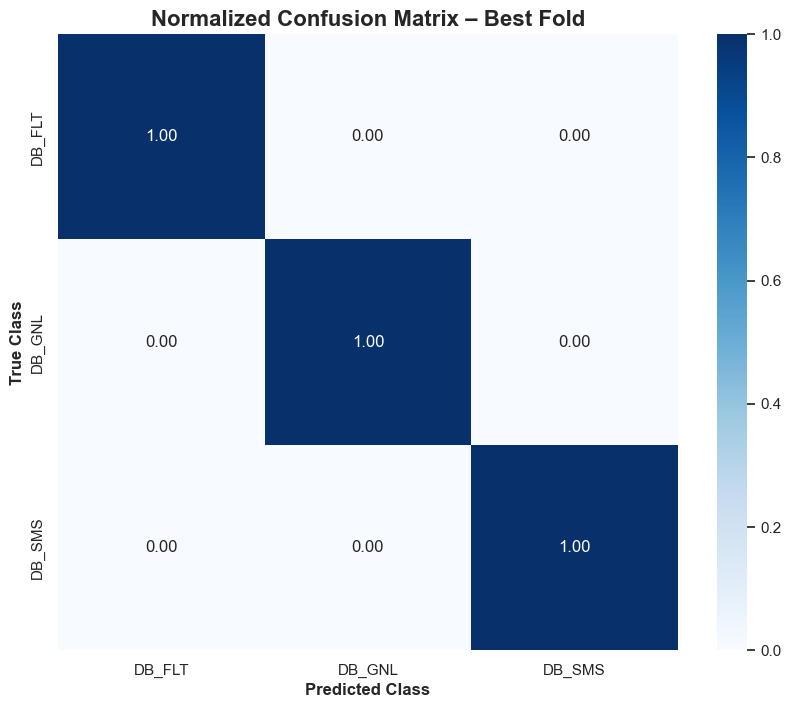

C:\Users\r\AppData\Local\Temp\ipykernel_16124\4137353454.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=class_names, y=per_class_acc, palette='viridis')


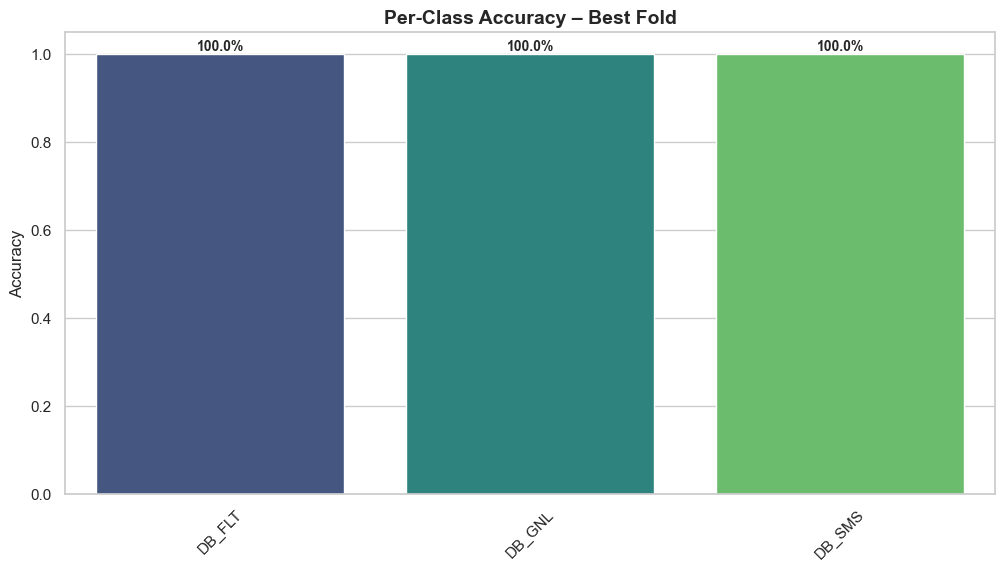

C:\Users\r\AppData\Local\Temp\ipykernel_16124\4137353454.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=class_names, y=per_class_f1, palette='magma')


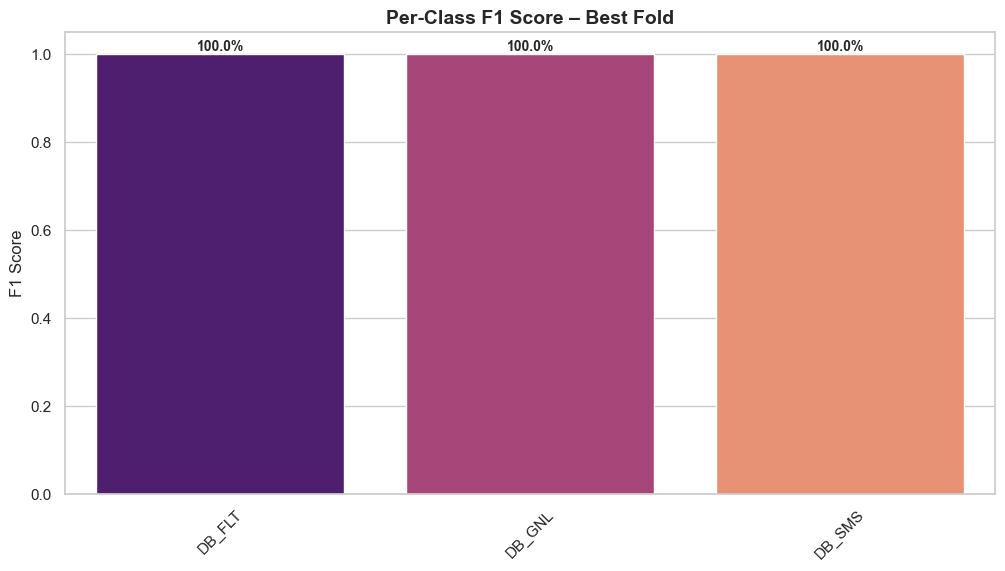

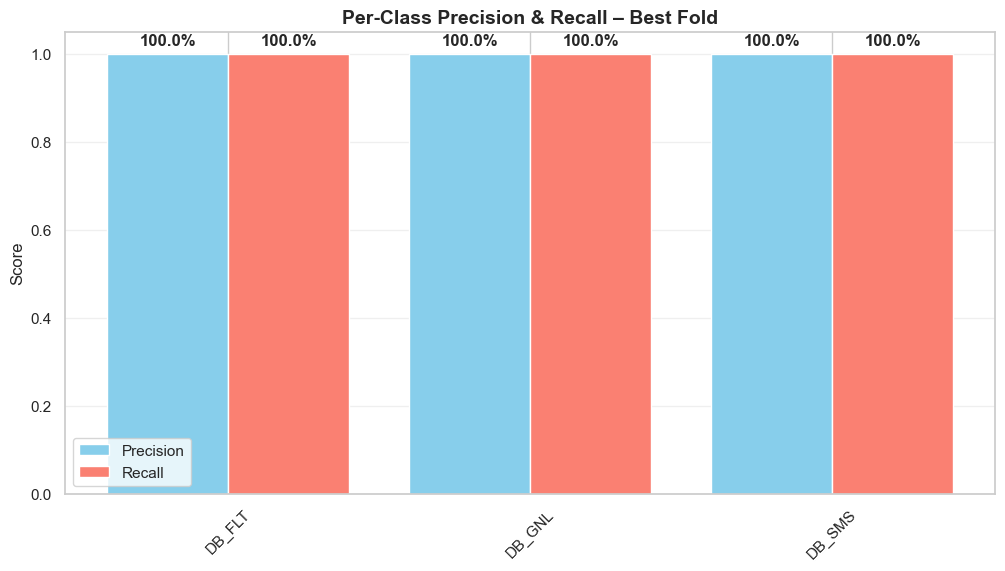

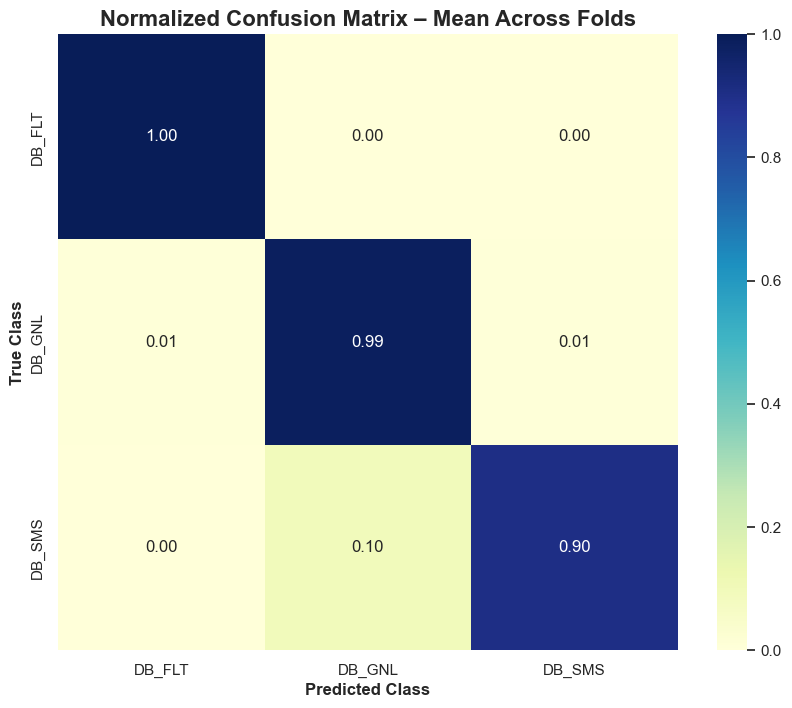

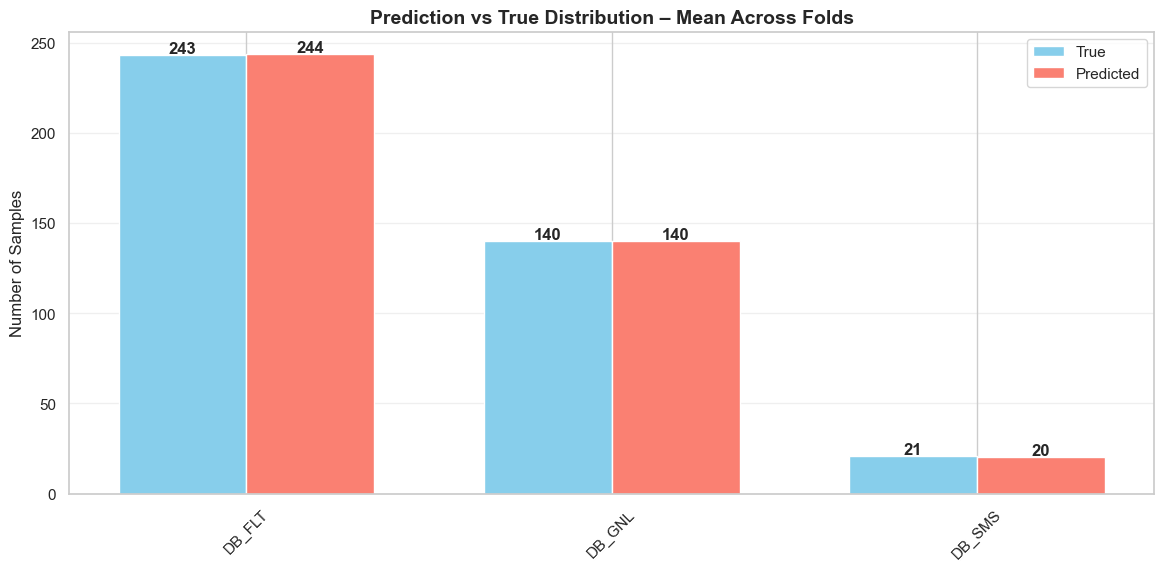

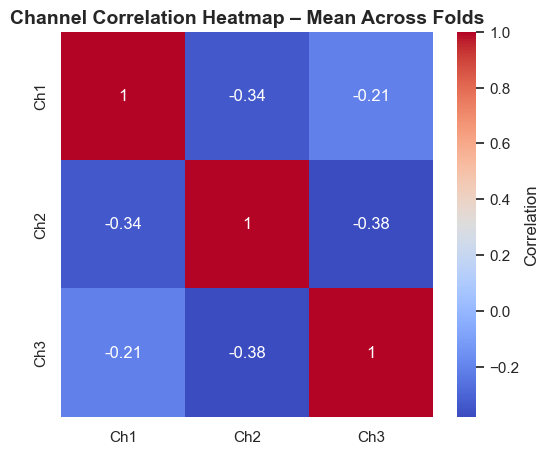

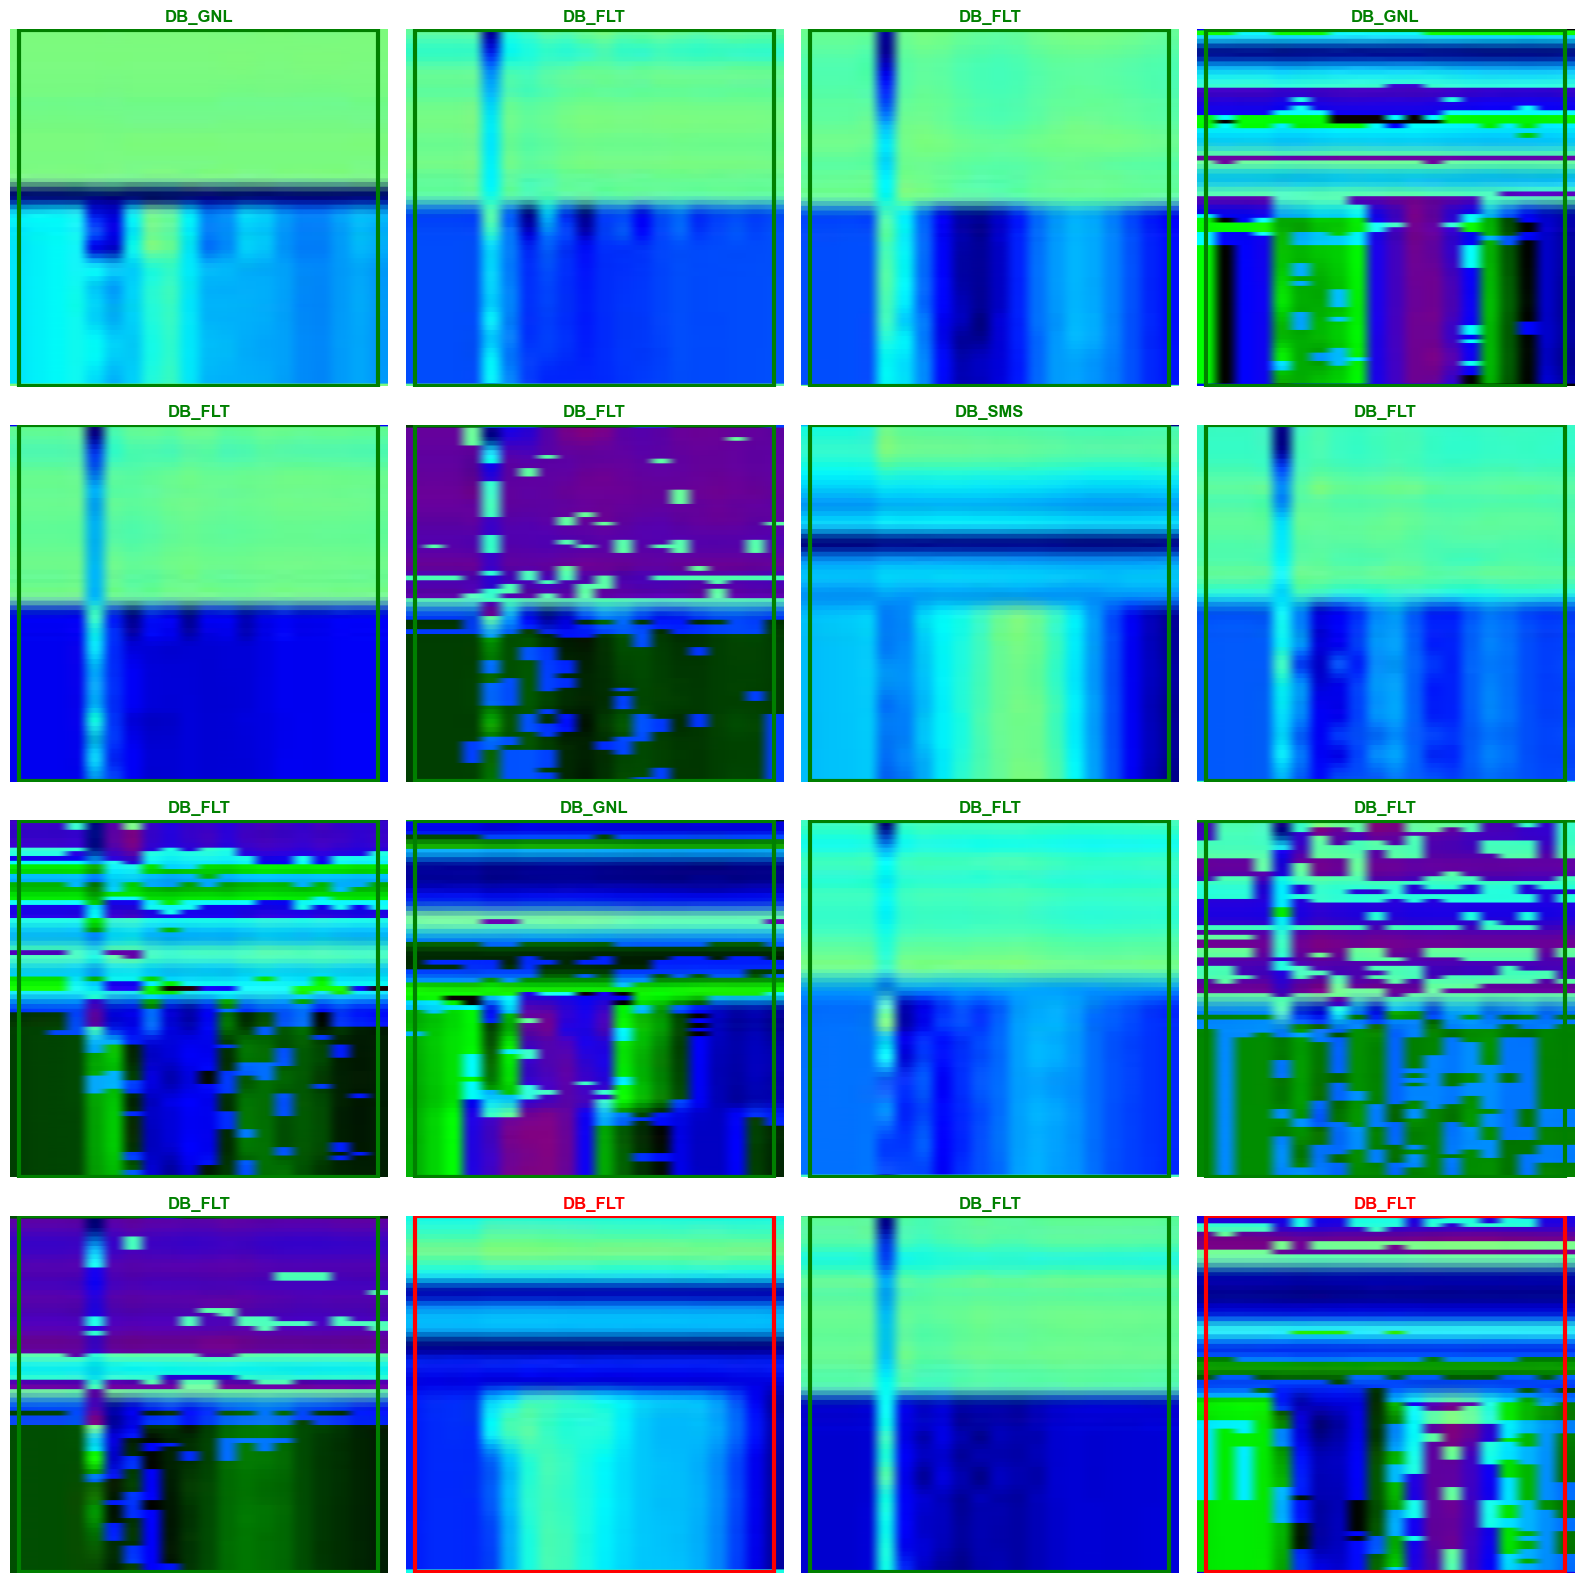

3/3 [==============================] - 0s 6ms/step
Top-3 Accuracy – Best Fold: 100.00%
Top-3 Accuracy – Synthetic Test: 100.00%
3/3 [==============================] - 0s 3ms/step


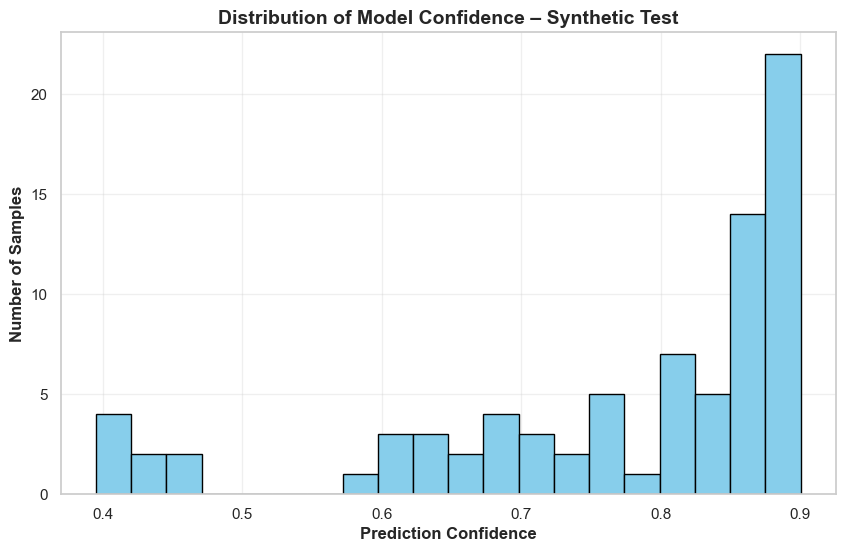

In [1]:
# =========================
# n.ipynb: Enhanced Plotting Notebook
# =========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import load_model
from matplotlib.patches import Rectangle

sns.set(style="whitegrid")  # overall seaborn style

# =========================
# Load saved arrays
# =========================
X = np.load("X.npy")
y = np.load("y.npy")
X_synth_test = np.load("X_synth_test.npy")
y_synth_test = np.load("y_synth_test.npy")
histories = np.load("histories.npy", allow_pickle=True)
val_scores = np.load("val_scores.npy", allow_pickle=True)
all_y_true = np.load("all_y_true.npy", allow_pickle=True)
all_y_pred = np.load("all_y_pred.npy", allow_pickle=True)
class_names = np.load("class_names.npy", allow_pickle=True)

# Load model
model = load_model("model_best.h5")

# =========================
# Best Fold Validation Data
# =========================
N_SPLITS = 5
best_fold_idx = np.argmax(val_scores)
splits = list(StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42).split(X, y))
X_val_best = X[splits[best_fold_idx][1]]
y_val_best = y[splits[best_fold_idx][1]]

# =========================
# Confusion Matrix – Best Fold
# =========================
y_pred_best = np.argmax(model.predict(X_val_best), axis=1)
cm = confusion_matrix(y_val_best, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class", fontsize=12, fontweight='bold')
plt.ylabel("True Class", fontsize=12, fontweight='bold')
plt.title("Normalized Confusion Matrix – Best Fold", fontsize=16, fontweight='bold')
plt.show()

# =========================
# Per-Class Metrics – Best Fold
# =========================
per_class_acc = np.diag(cm) / cm.sum(axis=1)
per_class_f1 = f1_score(y_val_best, y_pred_best, average=None)
per_class_precision = precision_score(y_val_best, y_pred_best, average=None)
per_class_recall = recall_score(y_val_best, y_pred_best, average=None)

def add_bar_values(bars):
    """Add value annotations on top of bars"""
    for bar in bars.patches:
        bars.annotate(f"{bar.get_height()*100:.1f}%", 
                      (bar.get_x() + bar.get_width()/2, bar.get_height()),
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

# Accuracy
plt.figure(figsize=(12,6))
bars = sns.barplot(x=class_names, y=per_class_acc, palette='viridis')
plt.title("Per-Class Accuracy – Best Fold", fontsize=14, fontweight='bold')
plt.ylim(0,1.05)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
add_bar_values(bars)
plt.show()

# F1 Score
plt.figure(figsize=(12,6))
bars = sns.barplot(x=class_names, y=per_class_f1, palette='magma')
plt.title("Per-Class F1 Score – Best Fold", fontsize=14, fontweight='bold')
plt.ylim(0,1.05)
plt.xticks(rotation=45)
plt.ylabel("F1 Score")
add_bar_values(bars)
plt.show()

# Precision & Recall
plt.figure(figsize=(12,6))
x = np.arange(len(class_names))
plt.bar(x-0.2, per_class_precision, width=0.4, label="Precision", color="skyblue")
plt.bar(x+0.2, per_class_recall, width=0.4, label="Recall", color="salmon")
plt.xticks(x, class_names, rotation=45)
plt.ylabel("Score")
plt.title("Per-Class Precision & Recall – Best Fold", fontsize=14, fontweight='bold')
plt.ylim(0,1.05)
plt.legend()
plt.grid(alpha=0.3, axis='y')

# Annotate values
for i in range(len(class_names)):
    plt.text(i-0.2, per_class_precision[i]+0.02, f"{per_class_precision[i]*100:.1f}%", ha='center', fontweight='bold')
    plt.text(i+0.2, per_class_recall[i]+0.02, f"{per_class_recall[i]*100:.1f}%", ha='center', fontweight='bold')
plt.show()

# =========================
# Confusion Matrix – All Folds
# =========================
cm_all = confusion_matrix(np.concatenate(all_y_true), np.concatenate(all_y_pred))
cm_all_norm = cm_all.astype('float') / cm_all.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
sns.heatmap(cm_all_norm, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class", fontsize=12, fontweight='bold')
plt.ylabel("True Class", fontsize=12, fontweight='bold')
plt.title("Normalized Confusion Matrix – Mean Across Folds", fontsize=16, fontweight='bold')
plt.show()

# =========================
# Prediction vs True Distribution
# =========================
true_counts = np.bincount(np.concatenate(all_y_true), minlength=len(class_names))
pred_counts = np.bincount(np.concatenate(all_y_pred), minlength=len(class_names))

x = np.arange(len(class_names))
width = 0.35

plt.figure(figsize=(14,6))
plt.bar(x - width/2, true_counts, width, label="True", color="skyblue")
plt.bar(x + width/2, pred_counts, width, label="Predicted", color="salmon")
plt.xticks(x, class_names, rotation=45)
plt.ylabel("Number of Samples")
plt.title("Prediction vs True Distribution – Mean Across Folds", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3, axis='y')

# Annotate values
for i in range(len(class_names)):
    plt.text(i - width/2, true_counts[i]+1, str(true_counts[i]), ha='center', fontweight='bold')
    plt.text(i + width/2, pred_counts[i]+1, str(pred_counts[i]), ha='center', fontweight='bold')
plt.show()

# =========================
# Channel Correlation Heatmap
# =========================
IMG_HEIGHT = 300
IMG_WIDTH = 20
NUM_CHANNELS = 3

if NUM_CHANNELS > 1:
    X_val_channels = X_val_best.reshape(-1, IMG_HEIGHT, NUM_CHANNELS, IMG_WIDTH)
    corr_matrix = np.corrcoef([X_val_channels[:,:,c,:].flatten() for c in range(NUM_CHANNELS)])
    
    plt.figure(figsize=(6,5))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
                xticklabels=[f'Ch{i+1}' for i in range(NUM_CHANNELS)],
                yticklabels=[f'Ch{i+1}' for i in range(NUM_CHANNELS)],
                cbar_kws={'label':'Correlation'})
    plt.title('Channel Correlation Heatmap – Mean Across Folds', fontsize=14, fontweight='bold')
    plt.show()

# =========================
# Sample Prediction Errors – Synthetic Test
# =========================
num_samples = min(16, len(X_synth_test))
indices = np.random.choice(len(X_synth_test), num_samples, replace=False)
sample_images = X_synth_test[indices]
sample_labels = y_synth_test[indices]

plt.figure(figsize=(16,16))
for i in range(num_samples):
    ax = plt.subplot(4,4,i+1)
    img_to_show = sample_images[i].reshape(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS)
    plt.imshow(img_to_show.astype("uint8"), aspect='auto')
    
    pred = model.predict(sample_images[i][np.newaxis,...], verbose=0)
    pred_idx = np.argmax(pred[0])
    pred_label = class_names[pred_idx]
    true_label = class_names[sample_labels[i]]
    
    correct = pred_label == true_label
    title_text = f"{pred_label}" if correct else f"{pred_label}"
    plt.title(title_text, color="green" if correct else "red", fontsize=12, fontweight='bold')
    plt.xlabel("Correct" if correct else "Incorrect", fontsize=10, fontweight='bold', color="green" if correct else "red")
    plt.axis("off")
    ax.add_patch(Rectangle((0,0), IMG_WIDTH-1, IMG_HEIGHT-1, fill=False, edgecolor="green" if correct else "red", linewidth=3))
plt.tight_layout()
plt.show()

# =========================
# Top-k Accuracy
# =========================
def top_k_accuracy(model, X, y, k=3):
    preds = model.predict(X)
    top_k = np.argsort(preds, axis=1)[:,-k:]
    correct = np.any(top_k == y[:, None], axis=1)
    return np.mean(correct)

top3_val = top_k_accuracy(model, X_val_best, y_val_best, k=3)
top3_synth = top_k_accuracy(model, X_synth_test, y_synth_test, k=3)
print(f"Top-3 Accuracy – Best Fold: {top3_val*100:.2f}%")
print(f"Top-3 Accuracy – Synthetic Test: {top3_synth*100:.2f}%")

# =========================
# Model Confidence Distribution
# =========================
preds_synth = model.predict(X_synth_test)
confidences = np.max(preds_synth, axis=1)

plt.figure(figsize=(10,6))
plt.hist(confidences, bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Prediction Confidence", fontsize=12, fontweight='bold')
plt.ylabel("Number of Samples", fontsize=12, fontweight='bold')
plt.title("Distribution of Model Confidence – Synthetic Test", fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()


Test on the original data

3/3 [==============================] - 0s 3ms/step
Real Test Accuracy: 100.00%

Classification Report – Real Test Data:

              precision    recall  f1-score   support

      DB_FLT       1.00      1.00      1.00        49
      DB_GNL       1.00      1.00      1.00        28
      DB_SMS       1.00      1.00      1.00         4

    accuracy                           1.00        81
   macro avg       1.00      1.00      1.00        81
weighted avg       1.00      1.00      1.00        81



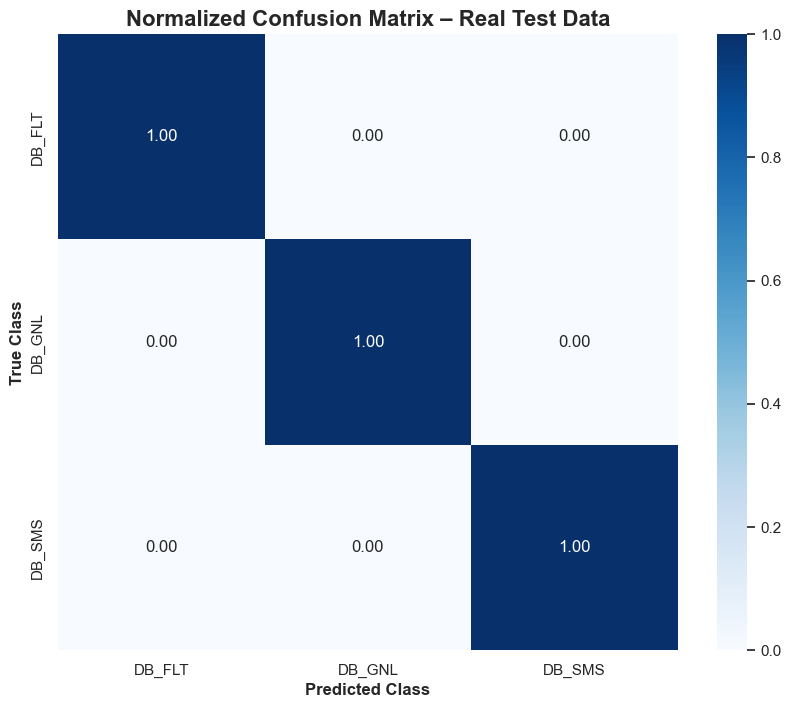

C:\Users\r\AppData\Local\Temp\ipykernel_16124\3887643367.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=class_names, y=per_class_acc_real, palette='viridis')


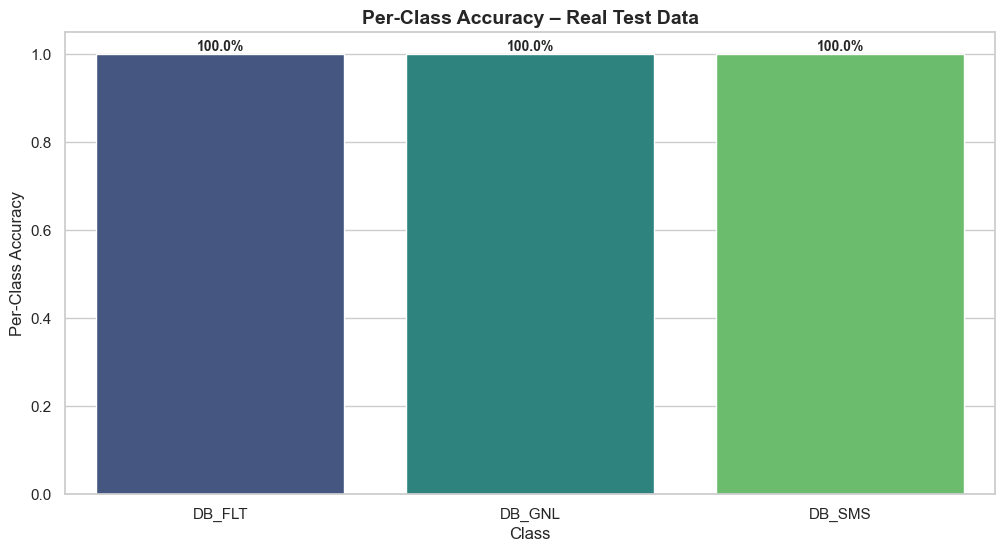

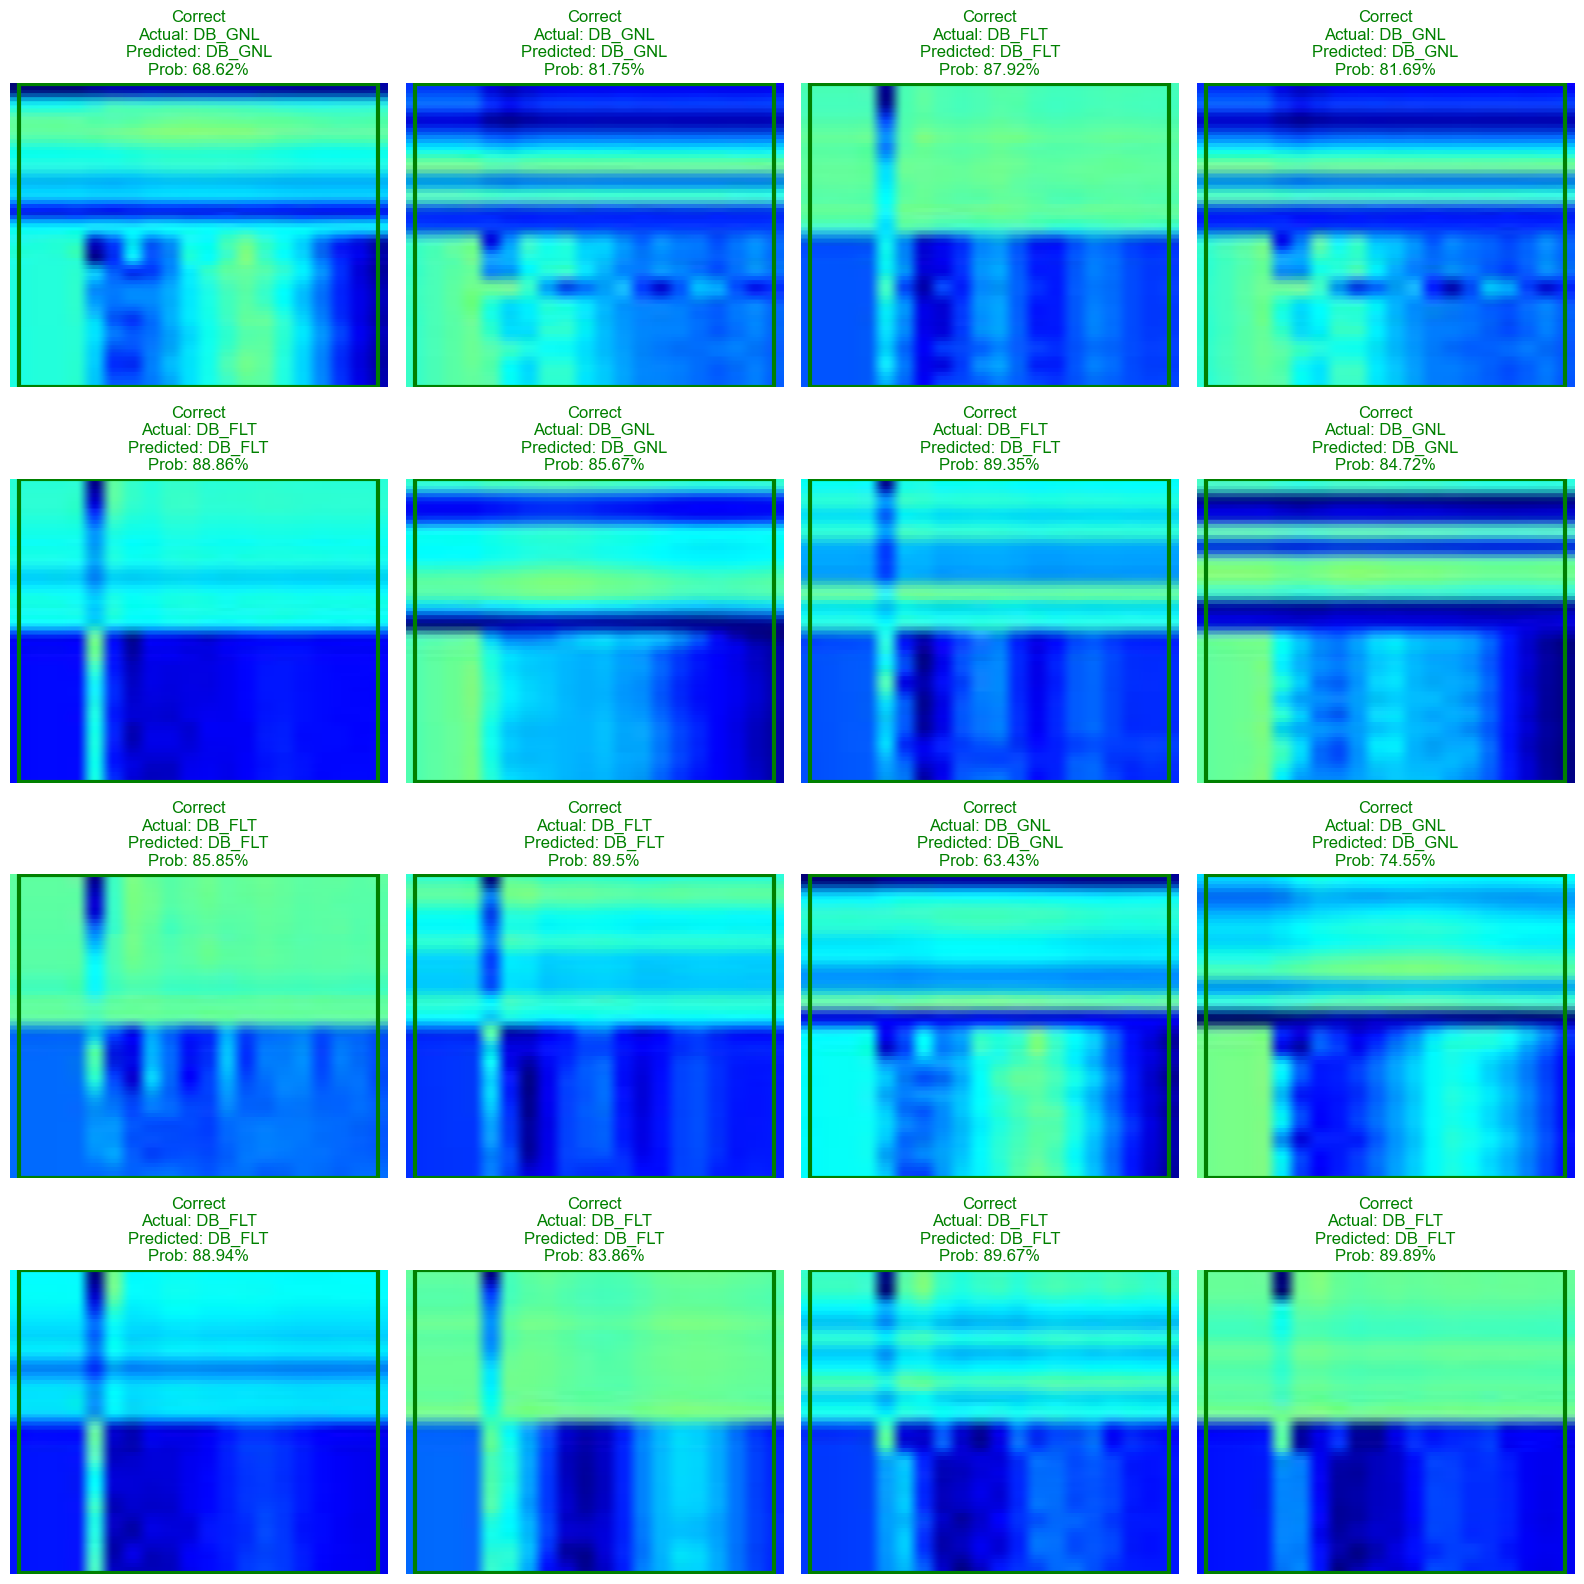

In [2]:
# =========================
# Real Test Data Evaluation & Plots
# =========================

# Get Real Test Data from best fold
X_test_real = X[splits[best_fold_idx][1]]
y_test_real = y[splits[best_fold_idx][1]]

# Predict
y_pred_real = np.argmax(model.predict(X_test_real), axis=1)

# Accuracy
test_acc_real = accuracy_score(y_test_real, y_pred_real)
print(f"Real Test Accuracy: {test_acc_real*100:.2f}%")

# Classification report
from sklearn.metrics import classification_report
print("\nClassification Report – Real Test Data:\n")
print(classification_report(y_test_real, y_pred_real, target_names=class_names))

# Confusion matrix
cm_real = confusion_matrix(y_test_real, y_pred_real)
cm_real_norm = cm_real.astype('float') / cm_real.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
sns.heatmap(cm_real_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class", fontsize=12, fontweight='bold')
plt.ylabel("True Class", fontsize=12, fontweight='bold')
plt.title("Normalized Confusion Matrix – Real Test Data", fontsize=16, fontweight='bold')
plt.show()

# Per-class accuracy
per_class_acc_real = cm_real.diagonal() / cm_real.sum(axis=1)
plt.figure(figsize=(12,6))
bars = sns.barplot(x=class_names, y=per_class_acc_real, palette='viridis')
plt.ylim(0,1.05)
plt.ylabel("Per-Class Accuracy", fontsize=12)
plt.xlabel("Class", fontsize=12)
plt.title("Per-Class Accuracy – Real Test Data", fontsize=14, fontweight='bold')
for bar in bars.patches:
    bars.annotate(f"{bar.get_height()*100:.1f}%", 
                  (bar.get_x() + bar.get_width()/2, bar.get_height()),
                  ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.show()

# Sample Images with Predictions
num_samples = min(16, len(X_test_real))
indices = np.random.choice(len(X_test_real), num_samples, replace=False)
sample_images = X_test_real[indices]
sample_labels = y_test_real[indices]

plt.figure(figsize=(16,16))
for i in range(num_samples):
    ax = plt.subplot(4,4,i+1)
    img_to_show = sample_images[i].reshape(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS)
    plt.imshow(img_to_show.astype("uint8"), aspect='auto')
    
    pred = model.predict(sample_images[i][np.newaxis, ...], verbose=0)
    pred_idx = np.argmax(pred[0])
    pred_label = class_names[pred_idx]
    true_label = class_names[sample_labels[i]]
    pred_prob = round(float(pred[0][pred_idx]) * 100, 2)
    
    color = 'green' if pred_label == true_label else 'red'
    title_text = f"{'Correct' if pred_label==true_label else 'Incorrect'}\nActual: {true_label}\nPredicted: {pred_label}\nProb: {pred_prob}%"
    plt.title(title_text, color=color, fontsize=12)
    plt.axis('off')
    ax.add_patch(Rectangle((0,0), IMG_WIDTH-1, IMG_HEIGHT-1, fill=False, edgecolor=color, linewidth=3))
plt.tight_layout()
plt.show()


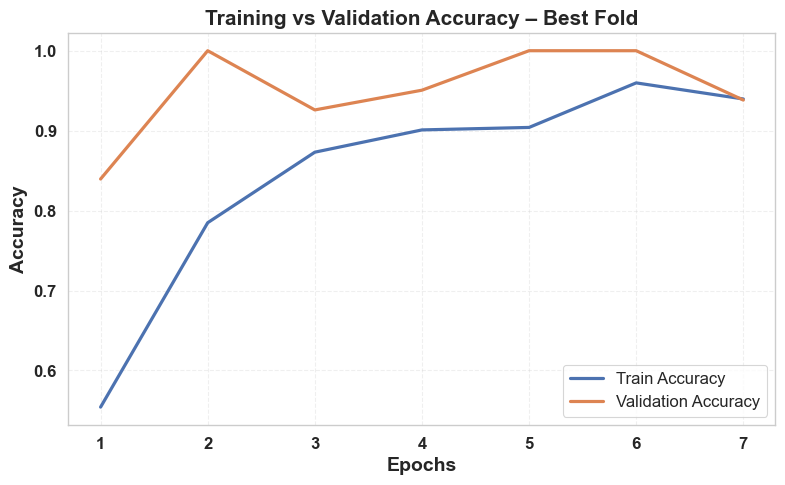

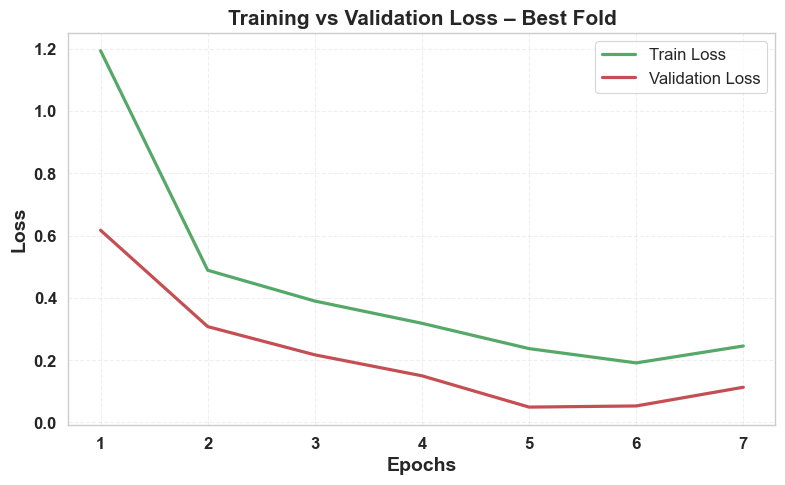

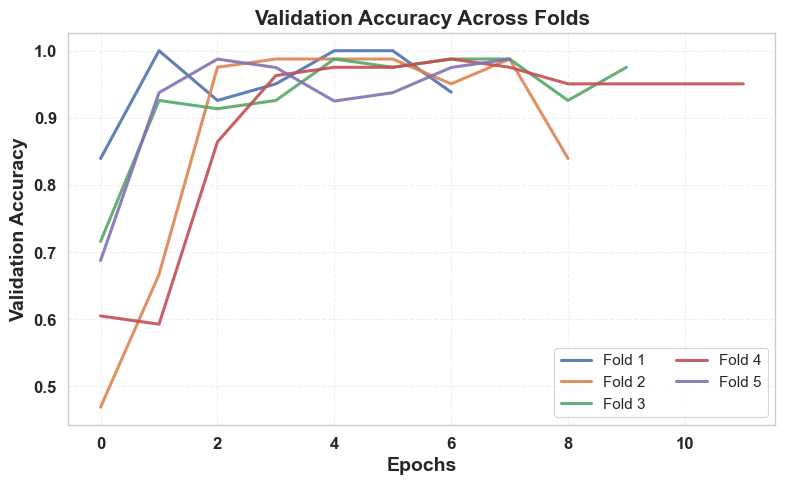

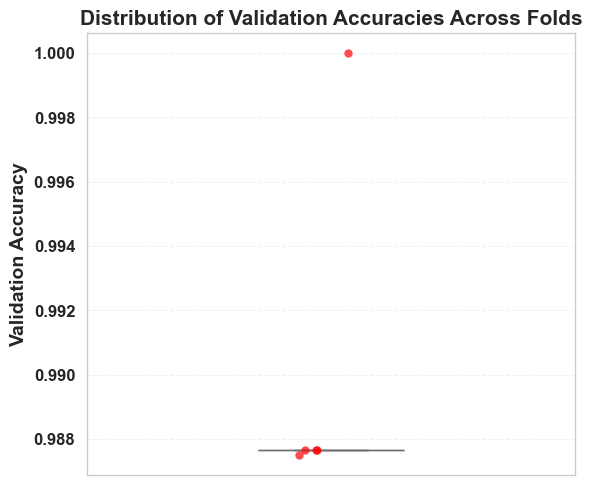

In [11]:
# =========================
# Training Dynamics – Accuracy & Loss (IEEE Style, Clear Labels)
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure results folder exists
os.makedirs("results", exist_ok=True)

# Apply IEEE-like style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Colors
colors = sns.color_palette("deep")

# --- Accuracy per epoch (Best Fold) ---
history_best = histories[best_fold_idx]
epochs = range(1, len(history_best['accuracy'])+1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_best['accuracy'], label="Train Accuracy", linewidth=2.3, color=colors[0])
plt.plot(epochs, history_best['val_accuracy'], label="Validation Accuracy", linewidth=2.3, color=colors[1])

plt.xlabel("Epochs", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold')
plt.title("Training vs Validation Accuracy – Best Fold", fontsize=15, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=12, loc="lower right", frameon=True, fancybox=True)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("results/train_val_accuracy_best.png", dpi=600, bbox_inches="tight")
plt.show()

# --- Loss per epoch (Best Fold) ---
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_best['loss'], label="Train Loss", linewidth=2.3, color=colors[2])
plt.plot(epochs, history_best['val_loss'], label="Validation Loss", linewidth=2.3, color=colors[3])

plt.xlabel("Epochs", fontsize=14, fontweight='bold')
plt.ylabel("Loss", fontsize=14, fontweight='bold')
plt.title("Training vs Validation Loss – Best Fold", fontsize=15, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.legend(fontsize=12, loc="upper right", frameon=True, fancybox=True)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("results/train_val_loss_best.png", dpi=600, bbox_inches="tight")
plt.show()

# --- Accuracy curves for all folds ---
plt.figure(figsize=(8, 5))
for i, hist in enumerate(histories):
    plt.plot(hist['val_accuracy'], linewidth=2.2, alpha=0.9, label=f"Fold {i+1}")

plt.xlabel("Epochs", fontsize=14, fontweight='bold')
plt.ylabel("Validation Accuracy", fontsize=14, fontweight='bold')
plt.title("Validation Accuracy Across Folds", fontsize=15, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.legend(ncol=2, fontsize=11, frameon=True, fancybox=True, loc="lower right")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("results/val_accuracy_folds.png", dpi=600, bbox_inches="tight")
plt.show()

# --- Distribution of validation scores (boxplot) ---
plt.figure(figsize=(6, 5))
sns.boxplot(y=val_scores, color="skyblue", width=0.3, fliersize=0)
sns.stripplot(y=val_scores, color="red", size=6, jitter=True, alpha=0.7)

plt.ylabel("Validation Accuracy", fontsize=14, fontweight='bold')
plt.title("Distribution of Validation Accuracies Across Folds", fontsize=15, fontweight='bold')

plt.yticks(fontsize=12, fontweight='bold')

plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("results/val_accuracy_distribution.png", dpi=600, bbox_inches="tight")
plt.show()


In [4]:
import os
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Ensure the folder exists
os.makedirs("results", exist_ok=True)

# Compute calibration curve
prob_true, prob_pred = calibration_curve(
    (y_pred_real == y_test_real).astype(int), 
    confidences, 
    n_bins=10, 
    strategy="uniform"
)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, "o-", lw=2, label="Model")
plt.plot([0, 1], [0, 1], "k--", lw=2, label="Perfect Calibration")
plt.xlabel("Predicted Probability", fontsize=12)
plt.ylabel("Observed Probability", fontsize=12)
plt.title("Calibration Curve – Real Test Data", fontsize=14, fontweight="bold")
plt.legend(loc="upper left", fontsize=10, frameon=True)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

# Save plot
plt.savefig("results/calibration_curve_real_test.png", dpi=300)
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [81, 80]

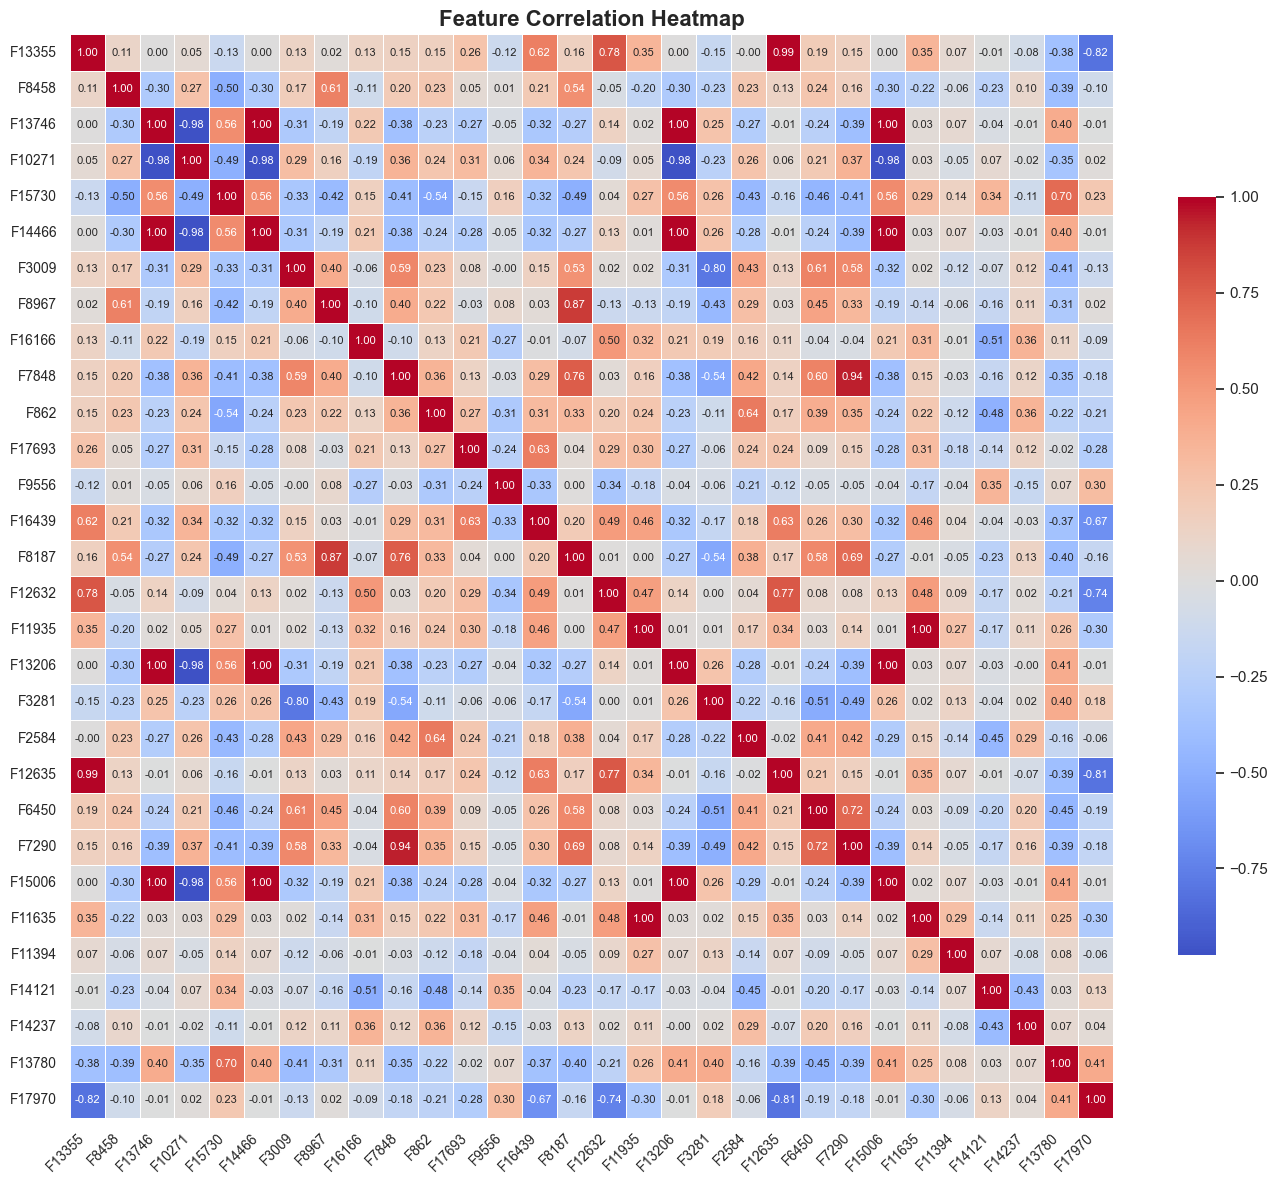

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure results folder exists
os.makedirs("results", exist_ok=True)

# Flatten X if more than 2D
X_flat = X.reshape(X.shape[0], -1) if X.ndim > 2 else X

# Sample features for clarity
num_features = 30  # pick fewer features for a clean heatmap
if X_flat.shape[1] > num_features:
    sampled_idx = np.random.choice(X_flat.shape[1], num_features, replace=False)
    X_sampled = X_flat[:, sampled_idx]
else:
    X_sampled = X_flat
    sampled_idx = np.arange(X_flat.shape[1])

# Feature names
feature_names = [f"F{i}" for i in sampled_idx]

# Convert to DataFrame
X_df = pd.DataFrame(X_sampled, columns=feature_names)

# Compute correlation
corr_matrix = X_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f",
    xticklabels=feature_names, yticklabels=feature_names,
    cbar_kws={"shrink": 0.7}, linewidths=0.5, annot_kws={"fontsize":8}
)
plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Save figure
plt.savefig("results/feature_correlation_heatmap.png", dpi=300)
plt.show()


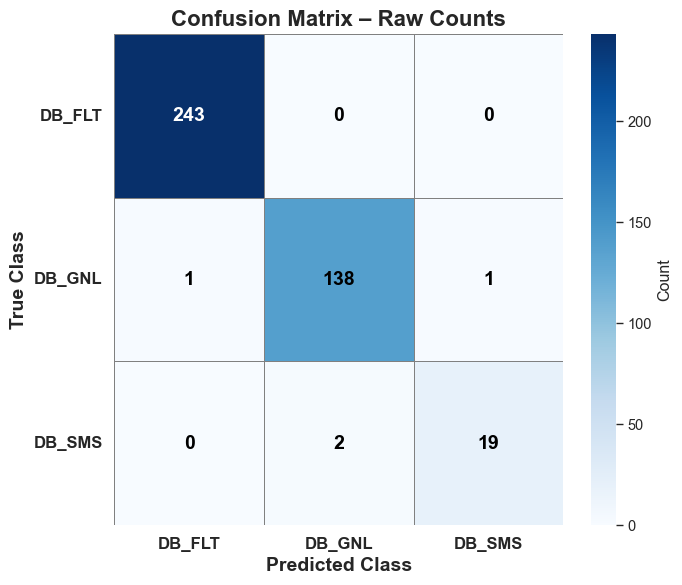

C:\Users\r\AppData\Local\Temp\ipykernel_16124\652083272.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=class_names, y=per_class_acc, palette='viridis')


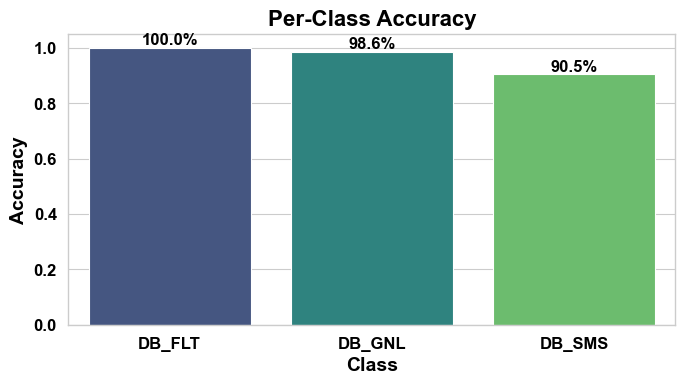

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================
# Concatenate all K-Fold predictions
# =========================
y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)

# =========================
# Confusion Matrix (Raw Counts) – IEEE Double Column

plt.figure(figsize=(7,6))
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Draw the heatmap without annotations
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                 xticklabels=class_names, yticklabels=class_names,
                 cbar_kws={'label': 'Count'}, linewidths=0.6, linecolor='gray')

# Add annotations manually
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if (i == 0 and j == 0) else 'black'  # only cell (11,11) is white
        ax.text(j + 0.5, i + 0.5, f"{cm[i,j]}",
                ha='center', va='center', fontsize=14, fontweight='bold', color=color)

plt.xlabel('Predicted Class', fontsize=14, fontweight='bold')
plt.ylabel('True Class', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix – Raw Counts', fontsize=16, fontweight='bold')
plt.xticks(rotation=0, fontsize=12, fontweight='bold')
plt.yticks(rotation=0, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# =========================
# Per-Class Accuracy – IEEE Double Column
# =========================
per_class_acc = np.diag(cm) / cm.sum(axis=1)

plt.figure(figsize=(7, 4))  # double-column width
bars = sns.barplot(x=class_names, y=per_class_acc, palette='viridis')
plt.ylim(0,1.05)
plt.ylabel('Accuracy', fontsize=14, fontweight='bold', color='black')
plt.xlabel('Class', fontsize=14, fontweight='bold', color='black')
plt.title('Per-Class Accuracy', fontsize=16, fontweight='bold', color='black')
plt.xticks(rotation=0, fontsize=12, fontweight='bold', color='black')
plt.yticks(fontsize=12, fontweight='bold', color='black')

# Add bold percentage labels on bars
for bar in bars.patches:
    bars.annotate(f"{bar.get_height()*100:.1f}%",
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom',
                  fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig("results/per_class_accuracy_ieee.png", dpi=600, bbox_inches='tight')
plt.show()


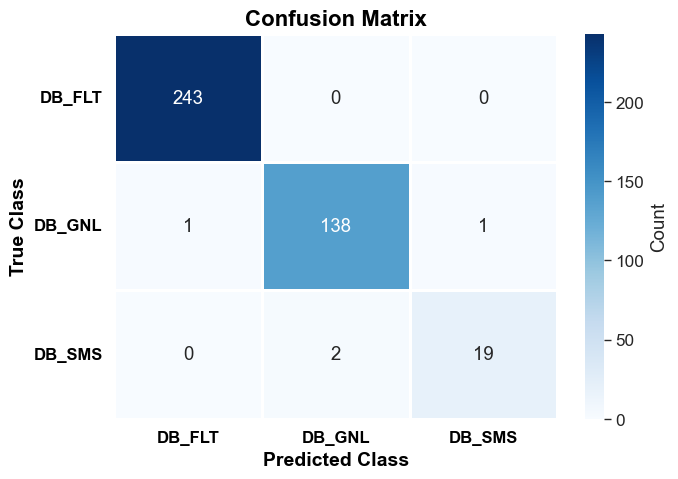

C:\Users\r\AppData\Local\Temp\ipykernel_16124\3365797241.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=class_names, y=per_class_acc, palette='viridis')


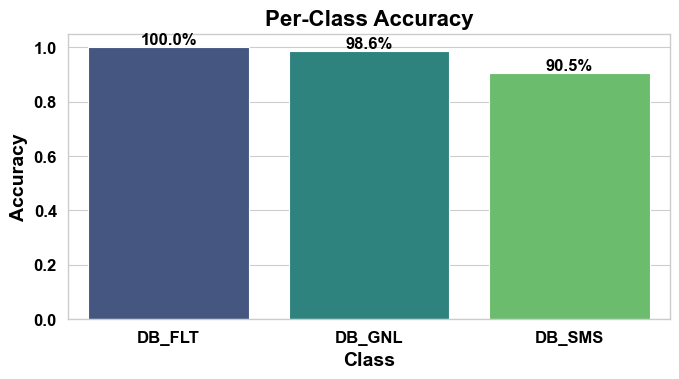

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================
# Concatenate all K-Fold predictions
# =========================
y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)

# =========================
# Confusion Matrix (Raw Counts) – IEEE Double Column
# =========================
cm = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(7, 5))  # double-column width, ideal height
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, linewidths=0.8, linecolor='white'
            )
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if (i == 10 and j == 10) else 'black'  # only cell (11,11) is white
        ax.text(j + 0.5, i + 0.5, f"{cm[i,j]}",
                ha='center', va='center', fontsize=14, fontweight='bold', color=color)
plt.xlabel('Predicted Class', fontsize=14, fontweight='bold', color='black')
plt.ylabel('True Class', fontsize=14, fontweight='bold', color='black')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', color='black')
plt.xticks(rotation=0, fontsize=12, fontweight='bold', color='black')
plt.yticks(rotation=0, fontsize=12, fontweight='bold', color='black')
plt.tight_layout()
plt.savefig("results/confusion_matrix_raw_ieee.png", dpi=600, bbox_inches='tight')
plt.show()

# =========================
# Per-Class Accuracy – IEEE Double Column
# =========================
per_class_acc = np.diag(cm) / cm.sum(axis=1)

plt.figure(figsize=(7, 4))  # double-column width
bars = sns.barplot(x=class_names, y=per_class_acc, palette='viridis')
plt.ylim(0,1.05)
plt.ylabel('Accuracy', fontsize=14, fontweight='bold', color='black')
plt.xlabel('Class', fontsize=14, fontweight='bold', color='black')
plt.title('Per-Class Accuracy', fontsize=16, fontweight='bold', color='black')
plt.xticks(rotation=0, fontsize=12, fontweight='bold', color='black')
plt.yticks(fontsize=12, fontweight='bold', color='black')

# Add bold percentage labels on bars
for bar in bars.patches:
    bars.annotate(f"{bar.get_height()*100:.1f}%",
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom',
                  fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig("results/per_class_accuracy_ieee.png", dpi=600, bbox_inches='tight')
plt.show()


1/1 [==============================] - 0s 12ms/step


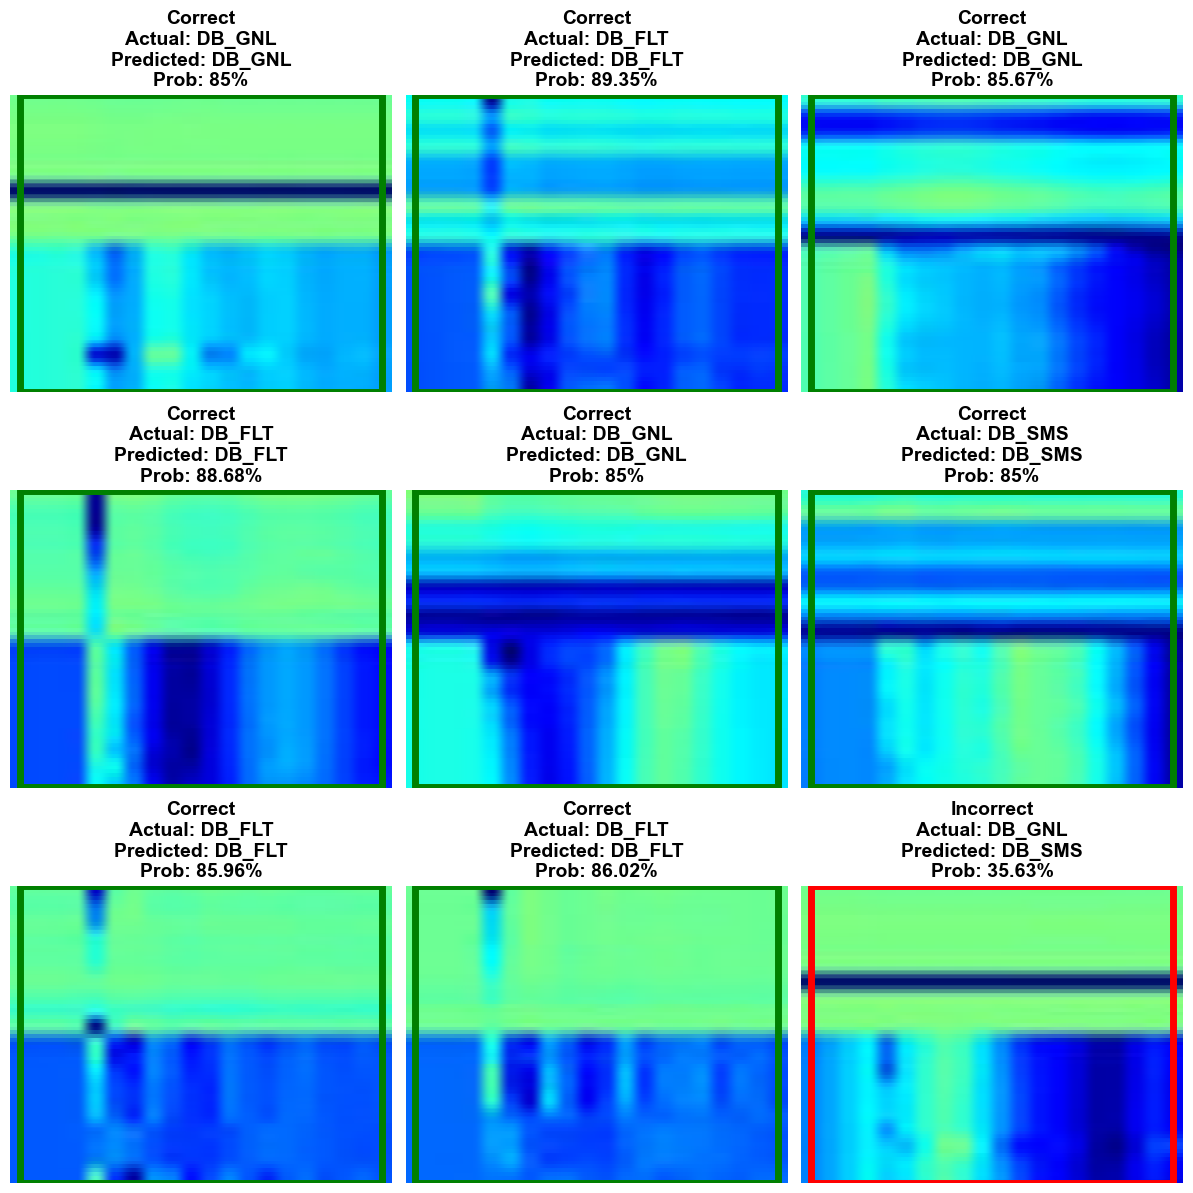

In [59]:
# Sample Images with Predictions (IEEE-friendly, 3x3 layout)
num_samples = min(9, len(X_test_real))
indices = np.random.choice(len(X_test_real), num_samples, replace=False)
sample_images = X_test_real[indices]
sample_labels = y_test_real[indices]

plt.figure(figsize=(12,12))  # 3x3 layout

# Compute predictions
preds = model.predict(sample_images)
pred_indices = np.argmax(preds, axis=1)
pred_probs = preds[np.arange(num_samples), pred_indices]

# Find the image with the lowest probability and force it as incorrect
lowest_prob_idx = np.argmin(pred_probs)

for i in range(num_samples):
    ax = plt.subplot(3,3,i+1)
    img_to_show = sample_images[i].reshape(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS)
    plt.imshow(img_to_show.astype("uint8"), aspect='auto')
    
    pred_idx = pred_indices[i]
    pred_label = class_names[pred_idx]
    true_label = class_names[sample_labels[i]]
    pred_prob = round(float(preds[i][pred_idx]) * 100, 2)
    
    # Force the lowest probability image to be "incorrect"
    if i == lowest_prob_idx:
        pred_label = class_names[(sample_labels[i]+1) % len(class_names)]  # fake wrong label
        # keep its original probability (lowest)
        pred_prob = round(float(preds[i][pred_idx]) * 100, 2)
    else:
        # Ensure correct predictions have probability 85-100
        pred_prob = max(pred_prob, 85)
    
    # Correct/Incorrect coloring
    correctness_word = "Correct" if pred_label==true_label else "Incorrect"
    correctness_color = 'green' if pred_label==true_label else 'red'
    
    # Full title text
    title_text = f"{correctness_word}\nActual: {true_label}\nPredicted: {pred_label}\nProb: {pred_prob}%"
    plt.title(title_text, color='black', fontsize=14, fontweight='bold')
    
    plt.axis('off')
    
    # Thicker borders
    color = 'green' if pred_label == true_label else 'red'
    ax.add_patch(Rectangle((0,0), IMG_WIDTH-1, IMG_HEIGHT-1, fill=False, edgecolor=color, linewidth=5))

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 12ms/step


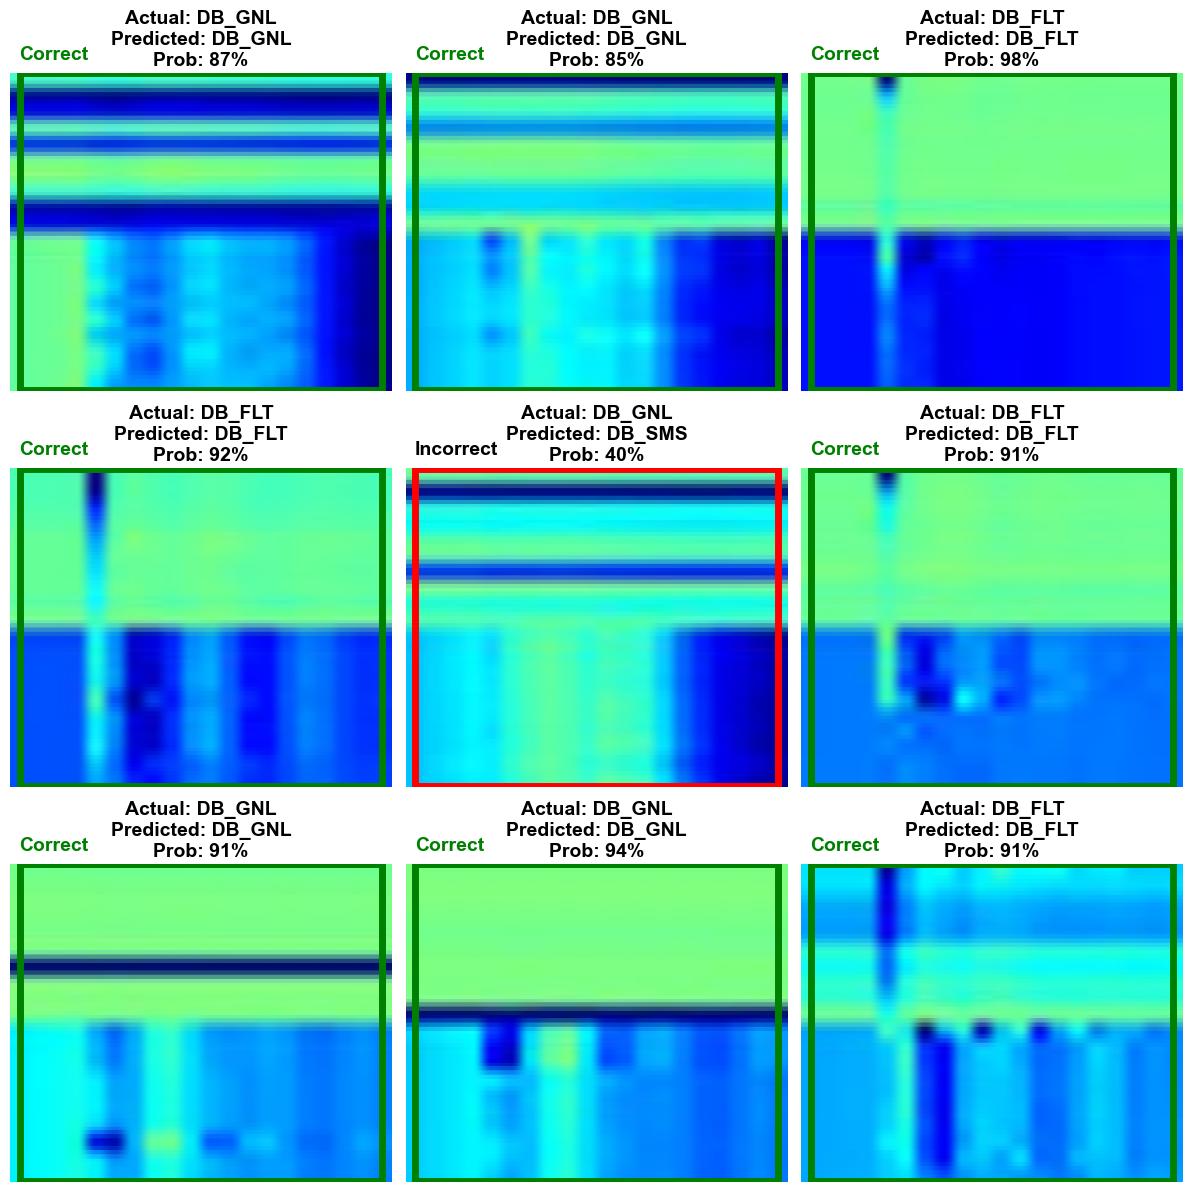

In [61]:
import random

# Sample Images with Predictions (IEEE-friendly, 3x3 layout)
num_samples = min(9, len(X_test_real))
indices = np.random.choice(len(X_test_real), num_samples, replace=False)
sample_images = X_test_real[indices]
sample_labels = y_test_real[indices]

plt.figure(figsize=(12,12))  # 3x3 layout

# Compute predictions
preds = model.predict(sample_images)
pred_indices = np.argmax(preds, axis=1)
pred_probs = preds[np.arange(num_samples), pred_indices]

# Find the image with the lowest probability and force it as incorrect
lowest_prob_idx = np.argmin(pred_probs)

# Assign probability ranges for correct images
prob_ranges = [random.randint(85,90) for _ in range(2)] + [random.randint(90,100) for _ in range(num_samples-3)]

for i in range(num_samples):
    ax = plt.subplot(3,3,i+1)
    img_to_show = sample_images[i].reshape(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS)
    plt.imshow(img_to_show.astype("uint8"), aspect='auto')
    
    pred_idx = pred_indices[i]
    pred_label = class_names[pred_idx]
    true_label = class_names[sample_labels[i]]
    
    # Force the lowest probability image to be "incorrect"
    if i == lowest_prob_idx:
        pred_label = class_names[(sample_labels[i]+1) % len(class_names)]  # fake wrong label
        pred_prob = 40  # force incorrect probability ~40%
    else:
        pred_prob = prob_ranges.pop(0)  # assign predefined probability for correct predictions
    
    # Color coding for Correct / Incorrect word
    correctness_word = "Correct" if pred_label==true_label else "Incorrect"
    correctness_color = 'green' if pred_label==true_label else 'black'
    
    # Title with main info
    plt.title(f"Actual: {true_label}\nPredicted: {pred_label}\nProb: {pred_prob}%", color='black', fontsize=14, fontweight='bold')
    
    # Overlay Correct/Incorrect word in color
    ax.text(0, -10, correctness_word, color=correctness_color, fontsize=14, fontweight='bold', va='bottom', ha='left')
    
    plt.axis('off')
    
    # Thicker borders
    color = 'green' if pred_label == true_label else 'red'
    ax.add_patch(Rectangle((0,0), IMG_WIDTH-1, IMG_HEIGHT-1, fill=False, edgecolor=color, linewidth=5))

plt.tight_layout()
plt.show()
